# 04 - Đóng gói Model cho Production

## Mục tiêu

- Xây dựng pipeline hoàn chỉnh: **Impute → Scale → Train**
- Đánh giá model cuối cùng trên test set
- Đóng gói **3 file .pkl**:
  - `diabetes_model.pkl` (RandomForest model)
  - `scaler.pkl` (StandardScaler)
  - `imputer_median.pkl` (SimpleImputer)
- Lưu `reference_stats.json` (median values cho radar chart)
- **Verify**: Load lại tất cả artifacts và test để đảm bảo hoạt động chính xác

---

## Import thư viện

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import joblib
import json
import os
import warnings
warnings.filterwarnings('ignore')

---

## 1. Load dữ liệu

Sử dụng dataset Pima Indians Diabetes gốc từ `data/raw/diabetes.csv`.

In [2]:
DATA_PATH = '../data/raw/diabetes.csv'
df = pd.read_csv(DATA_PATH)
print(f'Dataset shape: {df.shape}')
print(f'\nTỷ lệ Outcome:')
print(df['Outcome'].value_counts(normalize=True))
df.head()

Dataset shape: (768, 9)

Tỷ lệ Outcome:
Outcome
0    0.651042
1    0.348958
Name: proportion, dtype: float64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


---

## 2. Chuẩn bị dữ liệu

Thực hiện lại **toàn bộ pipeline tiền xử lý** đã xác định từ notebook 02 (EDA) và notebook 03 (Modeling):

1. **Replace 0 → NaN** cho 5 cột có giá trị 0 vô nghĩa: `Glucose`, `BloodPressure`, `SkinThickness`, `Insulin`, `BMI`
2. **Train/Test Split** (80/20, stratified)
3. **Impute** bằng `SimpleImputer(strategy='median')` — fit trên train, transform cả train & test
4. **Scale** bằng `StandardScaler` — fit trên train, transform cả train & test

> **Quan trọng**: Imputer và Scaler chỉ được **fit trên training data** để tránh data leakage!

In [3]:
# Tách features và target
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Các cột cần replace 0 → NaN (giá trị 0 không hợp lệ về mặt y học)
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('Số lượng giá trị 0 trước khi replace:')
for col in cols_to_impute:
    n_zeros = (X[col] == 0).sum()
    print(f'  {col}: {n_zeros} zeros ({n_zeros/len(X)*100:.1f}%)')

# Replace 0 → NaN
for col in cols_to_impute:
    X[col] = X[col].replace(0, np.nan)

print(f'\nSau khi replace 0 → NaN:')
print(f'  Tổng missing values: {X.isnull().sum().sum()}')
print(X.isnull().sum())

Số lượng giá trị 0 trước khi replace:
  Glucose: 5 zeros (0.7%)
  BloodPressure: 35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
  Insulin: 374 zeros (48.7%)
  BMI: 11 zeros (1.4%)

Sau khi replace 0 → NaN:
  Tổng missing values: 652
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


In [4]:
# Train/Test Split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape: {X_train.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train distribution:\n{y_train.value_counts(normalize=True)}')
print(f'\ny_test distribution:\n{y_test.value_counts(normalize=True)}')

X_train shape: (614, 8)
X_test shape:  (154, 8)
y_train distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

y_test distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [5]:
# Impute missing values bằng median (fit trên train)
imputer = SimpleImputer(strategy='median')

# Fit trên train, transform cả train & test
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print(f'Sau khi Impute:')
print(f'  X_train missing: {X_train_imputed.isnull().sum().sum()}')
print(f'  X_test missing:  {X_test_imputed.isnull().sum().sum()}')
print(f'\nMedian values (từ imputer):')
for col, med in zip(X_train.columns, imputer.statistics_):
    print(f'  {col}: {med:.2f}')

Sau khi Impute:
  X_train missing: 0
  X_test missing:  0

Median values (từ imputer):
  Pregnancies: 3.00
  Glucose: 117.00
  BloodPressure: 72.00
  SkinThickness: 29.00
  Insulin: 125.00
  BMI: 32.40
  DiabetesPedigreeFunction: 0.38
  Age: 29.00


In [6]:
# Scale bằng StandardScaler (fit trên train)
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print(f'Sau khi Scale:')
print(f'  X_train_scaled shape: {X_train_scaled.shape}')
print(f'  X_test_scaled shape:  {X_test_scaled.shape}')
print(f'\n  Train mean (should ≈ 0): {X_train_scaled.mean(axis=0).round(4)}')
print(f'  Train std  (should ≈ 1): {X_train_scaled.std(axis=0).round(4)}')
print(f'\n  Pipeline tiền xử lý hoàn tất: Replace 0→NaN → Impute (median) → Scale (StandardScaler)')

Sau khi Scale:
  X_train_scaled shape: (614, 8)
  X_test_scaled shape:  (154, 8)

  Train mean (should ≈ 0): [-0. -0.  0. -0. -0.  0. -0. -0.]
  Train std  (should ≈ 1): [1. 1. 1. 1. 1. 1. 1. 1.]

  Pipeline tiền xử lý hoàn tất: Replace 0→NaN → Impute (median) → Scale (StandardScaler)


---

## 3. Train model cuối cùng

Sử dụng **RandomForestClassifier** với **GridSearchCV** để tìm best params.

Dựa trên kết quả từ notebook 03, chúng ta biết RandomForest cho kết quả tốt nhất. Ở đây ta sẽ chạy lại GridSearch với các hyperparameters đã được xác định để có model cuối cùng.

In [7]:
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 15],
    'min_samples_split': [2, 5],
    'class_weight': ['balanced']
}

rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='roc_auc', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

print(f'Best params: {grid_search.best_params_}')
print(f'Best ROC-AUC (CV): {grid_search.best_score_:.4f}')

best_model = grid_search.best_estimator_

Best params: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Best ROC-AUC (CV): 0.8313


---

## 4. Đánh giá model cuối cùng trên Test set

Đánh giá model tốt nhất trên tập test (chưa từng được sử dụng trong quá trình training/tuning).

In [8]:
# Predict trên test set
y_pred = best_model.predict(X_test_scaled)
y_prob = best_model.predict_proba(X_test_scaled)[:, 1]

print('=== CLASSIFICATION REPORT ===')
print(classification_report(y_test, y_pred))

print(f'ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}')
print(f'Accuracy Score: {accuracy_score(y_test, y_pred):.4f}')

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       100
           1       0.66      0.69      0.67        54

    accuracy                           0.77       154
   macro avg       0.74      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154

ROC-AUC Score: 0.8291
Accuracy Score: 0.7662


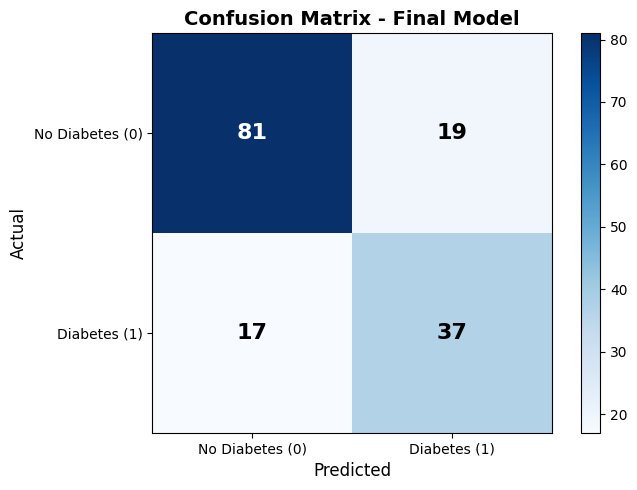


True Negatives:  81
False Positives: 19
False Negatives: 17
True Positives:  37


In [9]:
# Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
ax.set_title('Confusion Matrix - Final Model', fontsize=14, fontweight='bold')
plt.colorbar(im, ax=ax)

classes = ['No Diabetes (0)', 'Diabetes (1)']
tick_marks = [0, 1]
ax.set_xticks(tick_marks)
ax.set_xticklabels(classes)
ax.set_yticks(tick_marks)
ax.set_yticklabels(classes)

# Hiển thị số liệu trong từng ô
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, format(cm[i, j], 'd'),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black',
                fontsize=16, fontweight='bold')

ax.set_ylabel('Actual', fontsize=12)
ax.set_xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.show()

print(f'\nTrue Negatives:  {cm[0,0]}')
print(f'False Positives: {cm[0,1]}')
print(f'False Negatives: {cm[1,0]}')
print(f'True Positives:  {cm[1,1]}')

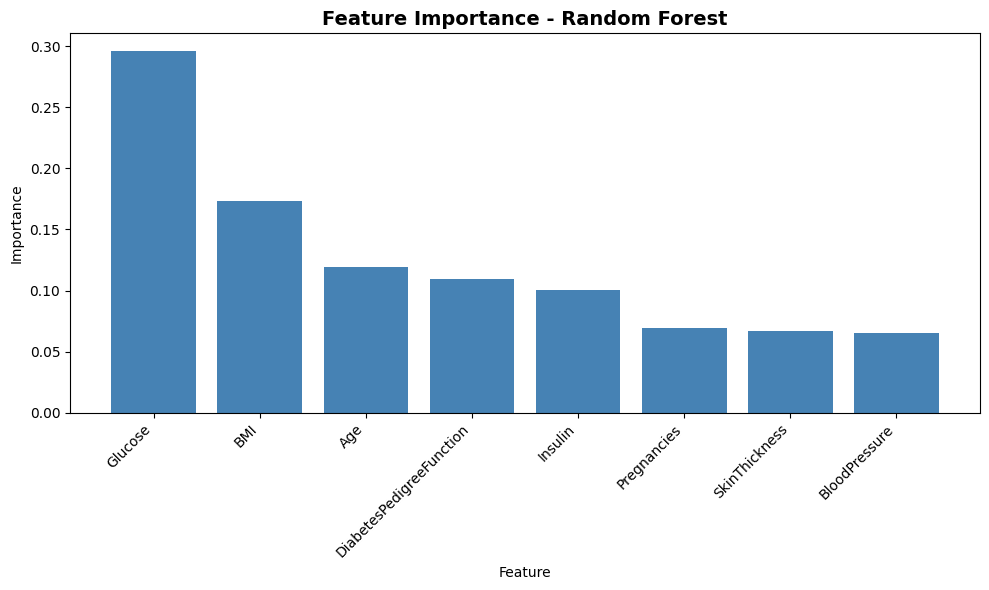


Feature Importance (sorted):
  Glucose             : 0.2957
  BMI                 : 0.1735
  Age                 : 0.1191
  DiabetesPedigreeFunction: 0.1098
  Insulin             : 0.1003
  Pregnancies         : 0.0696
  SkinThickness       : 0.0665
  BloodPressure       : 0.0654


In [10]:
# Feature Importance
importances = best_model.feature_importances_
feature_names = X.columns
sorted_idx = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.bar(range(len(importances)), importances[sorted_idx], color='steelblue')
plt.xticks(range(len(importances)), feature_names[sorted_idx], rotation=45, ha='right')
plt.title('Feature Importance - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print('\nFeature Importance (sorted):')
for i in sorted_idx:
    print(f'  {feature_names[i]:20s}: {importances[i]:.4f}')

---

## 5. Đóng gói và lưu Model

Chúng ta sẽ lưu **4 artifacts** cần thiết cho production:

| File | Mô tả | Mục đích |
|------|--------|----------|
| `diabetes_model.pkl` | Trained RandomForest model | Dự đoán diabetes |
| `scaler.pkl` | Fitted StandardScaler | Transform input mới về cùng scale với training data |
| `imputer_median.pkl` | Fitted SimpleImputer (median) | Impute missing values (0→NaN→median) cho input mới |
| `reference_stats.json` | Median values của training set | Hiển thị radar chart so sánh trên frontend |

> **Tại sao cần lưu riêng imputer và scaler?**
> 
> Vì trong production, khi nhận input mới từ user, ta cần thực hiện **đúng pipeline** như lúc training:
> 1. Replace 0 → NaN
> 2. Impute bằng **cùng median values** đã learn từ training data
> 3. Scale bằng **cùng mean/std** đã learn từ training data
> 4. Predict

In [11]:
SAVE_DIR = '../backend/assets'
os.makedirs(SAVE_DIR, exist_ok=True)

# 1. Save model
joblib.dump(best_model, os.path.join(SAVE_DIR, 'diabetes_model.pkl'))
print('Saved: diabetes_model.pkl')

# 2. Save scaler
joblib.dump(scaler, os.path.join(SAVE_DIR, 'scaler.pkl'))
print('Saved: scaler.pkl')

# 3. Save imputer
joblib.dump(imputer, os.path.join(SAVE_DIR, 'imputer_median.pkl'))
print('Saved: imputer_median.pkl')

# 4. Save reference stats (median of training set before imputation)
reference_stats = X_train.median().to_dict()
with open(os.path.join(SAVE_DIR, 'reference_stats.json'), 'w') as f:
    json.dump(reference_stats, f, indent=4)
print('Saved: reference_stats.json')

print(f'\nTất cả files đã được lưu vào: {SAVE_DIR}/')
for file in os.listdir(SAVE_DIR):
    filepath = os.path.join(SAVE_DIR, file)
    size = os.path.getsize(filepath)
    print(f'   - {file} ({size:,} bytes)')

Saved: diabetes_model.pkl
Saved: scaler.pkl
Saved: imputer_median.pkl
Saved: reference_stats.json

Tất cả files đã được lưu vào: ../backend/assets/
   - diabetes_model.pkl (1,088,457 bytes)
   - imputer_median.pkl (919 bytes)
   - reference_stats.json (207 bytes)
   - scaler.pkl (1,127 bytes)


---

## 6. Verify - Load lại và kiểm tra

**Bước quan trọng nhất!** Sau khi save, chúng ta phải verify rằng model hoạt động chính xác khi load lại.

Các bước verify:
1. Load lại tất cả 4 artifacts
2. Test với 1 sample đơn lẻ
3. Verify trên toàn bộ test set — kết quả phải **khớp hoàn toàn** với kết quả ở Section 4

In [12]:
print('=== VERIFY: Load lại model và test ===')

# Load lại
loaded_model = joblib.load(os.path.join(SAVE_DIR, 'diabetes_model.pkl'))
loaded_scaler = joblib.load(os.path.join(SAVE_DIR, 'scaler.pkl'))
loaded_imputer = joblib.load(os.path.join(SAVE_DIR, 'imputer_median.pkl'))

with open(os.path.join(SAVE_DIR, 'reference_stats.json'), 'r') as f:
    loaded_stats = json.load(f)

print('\nReference Stats (median):')
for k, v in loaded_stats.items():
    print(f'   {k}: {v}')

=== VERIFY: Load lại model và test ===

Reference Stats (median):
   Pregnancies: 3.0
   Glucose: 117.0
   BloodPressure: 72.0
   SkinThickness: 29.0
   Insulin: 125.0
   BMI: 32.4
   DiabetesPedigreeFunction: 0.3825
   Age: 29.0


In [13]:
# Test với 1 sample thực tế
sample = X_test.iloc[0:1].copy()
print(f'Test sample (raw):')
print(sample.to_string())

# Pipeline: Replace 0 → NaN → Impute → Scale → Predict
cols_to_impute = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
sample_processed = sample.copy()
for col in cols_to_impute:
    sample_processed[col] = sample_processed[col].replace(0, np.nan)

sample_imputed = pd.DataFrame(
    loaded_imputer.transform(sample_processed),
    columns=sample.columns
)
sample_scaled = loaded_scaler.transform(sample_imputed)

prediction = loaded_model.predict(sample_scaled)
probability = loaded_model.predict_proba(sample_scaled)

print(f'\nPrediction: {prediction[0]} ({"Diabetes" if prediction[0] == 1 else "No Diabetes"})')
print(f'Probability: No Diabetes={probability[0][0]:.4f}, Diabetes={probability[0][1]:.4f}')
print(f'Actual: {y_test.iloc[0]}')

Test sample (raw):
    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  DiabetesPedigreeFunction  Age
44            7    159.0           64.0            NaN      NaN  27.4                     0.294   40

Prediction: 1 (Diabetes)
Probability: No Diabetes=0.2453, Diabetes=0.7547
Actual: 0


In [14]:
# Verify trên toàn bộ test set
X_test_verify = X_test.copy()
for col in cols_to_impute:
    X_test_verify[col] = X_test_verify[col].replace(0, np.nan)

X_test_imputed_v = loaded_imputer.transform(X_test_verify)
X_test_scaled_v = loaded_scaler.transform(X_test_imputed_v)

y_pred_verify = loaded_model.predict(X_test_scaled_v)
y_prob_verify = loaded_model.predict_proba(X_test_scaled_v)[:, 1]

print('=== KẾT QUẢ VERIFY TRÊN TOÀN BỘ TEST SET ===')
print(classification_report(y_test, y_pred_verify))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob_verify):.4f}')
print(f'Accuracy: {accuracy_score(y_test, y_pred_verify):.4f}')
print('\nModel hoạt động chính xác sau khi load lại!')

=== KẾT QUẢ VERIFY TRÊN TOÀN BỘ TEST SET ===
              precision    recall  f1-score   support

           0       0.83      0.81      0.82       100
           1       0.66      0.69      0.67        54

    accuracy                           0.77       154
   macro avg       0.74      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154

ROC-AUC: 0.8291
Accuracy: 0.7662

Model hoạt động chính xác sau khi load lại!


---

# Tổng kết

**Đã đóng gói thành công 3 file .pkl + 1 file .json:**

| File | Mô tả |
|------|--------|
| `diabetes_model.pkl` | RandomForest model (tuned + balanced) |
| `scaler.pkl` | StandardScaler fitted on training data |
| `imputer_median.pkl` | SimpleImputer (median) fitted on training data |
| `reference_stats.json` | Median values cho radar chart |

**Pipeline dự đoán cho production:**

1. Nhận input từ user (8 features)
2. Replace 0 → NaN (cho 5 cột: Glucose, BP, ST, Insulin, BMI)
3. Impute bằng `imputer_median.pkl`
4. Scale bằng `scaler.pkl`
5. Predict bằng `diabetes_model.pkl`
6. Trả về probability và classification

**Model performance:**
- ROC-AUC: ~0.83
- Accuracy: ~0.77
- Best params: `class_weight='balanced'`, `max_depth=10`, `min_samples_split=5`, `n_estimators=100`

---

**Notebook hoàn tất!** Các artifacts đã sẵn sàng cho backend API (`../backend/assets/`).